# Data Analysis Mathematics, Algorithms and Modeling

## Team Information - ** TODO Fill the type of assignment**

**Team Members**

Name: Ayush Patel  
Student Number: 9033358

Name: Nikhil Shankar  
Student Number: 9026254

Name: Sreehari Prathap  
Student Number: 8903199


## Step 1: Install and Configure the IDE (e.g., Jupyter Notebook and VS Code)
- Install Anaconda (for Jupyter Notebook) and Visual Studio Code (VS Code).
  - Anaconda: Visit [anaconda.com](https://www.anaconda.com/products/individual) and download the appropriate installer for your operating system.
  - VS Code: Download and install from [Visual Studio Code](https://code.visualstudio.com/).
- Install Pandas Library
  - Open the terminal and run the following command: `pip install pandas`

## Step 2: Downloading the Dataset
We are using the Utrecht Fairness Recruitment dataset from [Kaggle], which can be downloaded directly via the link:
- URL: [https://www.kaggle.com/datasets/ictinstitute/utrecht-fairness-recruitment-dataset]

## Step 3 : Data Cleansing

### Data Cleansing Process for User Data (Talent Acquisition) from a CSV File

In [87]:
import pandas as pd
import matplotlib.pyplot as plt

file = "../data/Extended_Employee_Performance_and_Productivity_Data.csv"
df_unfiltered = pd.read_csv(file)
row_count = len(df_unfiltered)

print("Total number of datapoints(rows)", row_count)

Total number of datapoints(rows) 100000


##### Removing empty valued rows from the dataset
By giving axis as 0 we filter rows with any empty values. 

In [88]:
df = df_unfiltered.dropna(axis=0, how='any')
print("Total number of datapoints(rows)", len(df))

Total number of datapoints(rows) 100000


We understand that there are no rows with empty values. The dataset is now filtered for analysis so we can proceed to the next step. 

In [89]:
df.describe()
df.head()

,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,1,IT,Male,55,Specialist,2022-01-19 08:03:05.556036,2,High School,5,6750.0,33,32,22,2,0,14,66,0,2.63,False
1,2,Finance,Male,29,Developer,2024-04-18 08:03:05.556036,0,High School,5,7500.0,34,34,13,14,100,12,61,2,1.72,False
2,3,Finance,Male,55,Specialist,2015-10-26 08:03:05.556036,8,High School,3,5850.0,37,27,6,3,50,10,1,0,3.17,False
3,4,Customer Support,Female,48,Analyst,2016-10-22 08:03:05.556036,7,Bachelor,2,4800.0,52,10,28,12,100,10,0,1,1.86,False
4,5,Engineering,Female,36,Analyst,2021-07-23 08:03:05.556036,3,Bachelor,2,4800.0,38,11,29,13,100,15,9,1,1.25,False


In [90]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from scipy.stats import boxcox
import numpy as np
import statsmodels.api as sm

class DataFrameTransformer:
    def __init__(self, df):
        self.df = df

    def factor_to_numeric(self, columns):
        for col in columns:
            self.df[col] = LabelEncoder().fit_transform(self.df[col])
        return self.df

    def convert_dates_to_julian(self, date_column, new_column_name):
        self.df[date_column] = pd.to_datetime(self.df[date_column])
        self.df[new_column_name] = self.df[date_column].apply(lambda x: x.to_julian_date())
        return self.df

    def categorical_to_dummies(self, columns):
        self.df = pd.get_dummies(self.df, columns=columns, drop_first=True)
        return self.df

    def boxcox_transform(self, columns):
        for column in columns:
            self.df[column], _ = boxcox(self.df[column] + 1e-6)
        return self.df

    def plot_tukey_ladder(self, column):
        df_copy= df.copy()
        df_copy[f'{column}_x2'] = np.sign(df_copy[column]) * (np.abs(df_copy[column]) ** 2)
        df_copy[f'{column}_x3'] = np.sign(df_copy[column]) * (np.abs(df_copy[column]) ** 3)
        df_copy[f'{column}_ix'] = np.sign(df_copy[column]) / (np.abs(df_copy[column]) ** 1)
        df_copy[f'{column}_ix2'] = np.sign(df_copy[column]) / (np.abs(df_copy[column]) ** 2)
        DataFrameTransformer.plot_histogram(df_copy[[column, f'{column}_x2', 
                                                        f'{column}_x3',
                                                        f'{column}_ix',
                                                        f'{column}_ix2'
                                                        ]])

    def tukeys_ladder(self, df, column, power):
        df[column] = np.sign(df[column]) * (np.abs(df[column]) ** 2)
        return df


    def simple_linear_regression(self, y_column, x_column):
        X = sm.add_constant(self.df[x_column])
        y = self.df[y_column]
        model = sm.OLS(y, X).fit()
        return model.summary()

    def multiple_linear_regression(self, y_column, x_columns):
        X = sm.add_constant(self.df[x_columns])
        y = self.df[y_column]
        model = sm.OLS(y, X).fit()
        return model.summary()
    
    def plot_simple_linear_regression(self, y_column, x_column):
        """
        Plots the results of a Simple Linear Regression.
        """
        # Prepare data for regression
        X = sm.add_constant(self.df[x_column])
        y = self.df[y_column]
        model = sm.OLS(y, X).fit()
        predictions = model.predict(X)

        # Plot scatter of actual values
        plt.scatter(self.df[x_column], self.df[y_column], alpha=0.5, label="Actual Data")
        
        # Plot regression line
        plt.plot(self.df[x_column], predictions, color='red', label="Regression Line")
        
        # Add labels and title
        plt.xlabel(x_column)
        plt.ylabel(y_column)
        plt.title(f"Simple Linear Regression: {y_column} vs. {x_column}")
        plt.legend()
        plt.show()

    def plot_multiple_linear_regression(self, y_column, x_columns):
        """
        Plots residuals vs. predicted values for Multiple Linear Regression.
        """
        # Prepare data for regression
        X = sm.add_constant(self.df[x_columns])
        y = self.df[y_column]
        model = sm.OLS(y, X).fit()
        predictions = model.predict(X)
        residuals = y - predictions

        # Plot residuals vs. predicted values
        plt.scatter(predictions, residuals, alpha=0.5)
        plt.axhline(y=0, color='red', linestyle='--', label="Zero Error Line")
        
        # Add labels and title
        plt.xlabel("Predicted Values")
        plt.ylabel("Residuals")
        plt.title("Multiple Linear Regression: Residuals vs. Predicted Values")
        plt.legend()
        plt.show()
    
    def  plot_histogram_2(self):
        fig,axes = plt.subplots(4, int(len(self.df.columns)//4)+1, figsize=(15,15))
        for i, col_name in enumerate(self.df.columns):
            axes[i%4, i//4].hist(self.df[col_name], bins=100)
            axes[i%4, i//4].set_xlabel(col_name)
            axes[i%4, i//4].set_ylabel('Frequency')
        plt.tight_layout()
        plt.show()

    def plot_histogram(df):
        numeric_columns = df.select_dtypes(include=['number']).columns.tolist()
        fig,axes = plt.subplots(4, int(len(numeric_columns)//4)+1, figsize=(15,15))
        for i, col_name in enumerate(numeric_columns):
            axes[i%4, i//4].set_yscale('log')
            axes[i%4, i//4].hist(df[col_name], bins=100)
            axes[i%4, i//4].set_xlabel(col_name)
            axes[i%4, i//4].set_ylabel('Frequency')
        plt.tight_layout()
        plt.show()

#### **1. Converting factor variables to numeric**


In [91]:
print(df.columns)
display(df.head(2))

Index(['Employee_ID', 'Department', 'Gender', 'Age', 'Job_Title', 'Hire_Date',
       'Years_At_Company', 'Education_Level', 'Performance_Score',
       'Monthly_Salary', 'Work_Hours_Per_Week', 'Projects_Handled',
       'Overtime_Hours', 'Sick_Days', 'Remote_Work_Frequency', 'Team_Size',
       'Training_Hours', 'Promotions', 'Employee_Satisfaction_Score',
       'Resigned'],
      dtype='object')


,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,1,IT,Male,55,Specialist,2022-01-19 08:03:05.556036,2,High School,5,6750.0,33,32,22,2,0,14,66,0,2.63,False
1,2,Finance,Male,29,Developer,2024-04-18 08:03:05.556036,0,High School,5,7500.0,34,34,13,14,100,12,61,2,1.72,False


In [92]:
dataCleaner = DataFrameTransformer(df)
df_factor_to_numeric = dataCleaner.factor_to_numeric(['Department', 'Gender', 'Job_Title', 'Education_Level'])
display(df_factor_to_numeric.head(2))

,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,1,4,1,55,5,2022-01-19 08:03:05.556036,2,1,5,6750.0,33,32,22,2,0,14,66,0,2.63,False
1,2,2,1,29,2,2024-04-18 08:03:05.556036,0,1,5,7500.0,34,34,13,14,100,12,61,2,1.72,False


#### **2. Converting calendar dates to Julian**

In [93]:
dataCleaner = DataFrameTransformer(df_factor_to_numeric)
df_julian  = dataCleaner.convert_dates_to_julian('Hire_Date', 'Julian_Hire_Date')
display(df_julian.head(2))

,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,...,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned,Julian_Hire_Date
0,1,4,1,55,5,2022-01-19 08:03:05.556036,2,1,5,6750.0,...,32,22,2,0,14,66,0,2.63,False,2.459599e+06
1,2,2,1,29,2,2024-04-18 08:03:05.556036,0,1,5,7500.0,...,34,13,14,100,12,61,2,1.72,False,2.460419e+06


#### **3. Converting categorical values to dummies**

In [94]:
dataCleaner = DataFrameTransformer(df_julian)
df_dummies  = dataCleaner.categorical_to_dummies(['Department', 'Education_Level', 'Job_Title'])
display(df_dummies.head(2))

,Employee_ID,Gender,Age,Hire_Date,Years_At_Company,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,...,Department_8,Education_Level_1,Education_Level_2,Education_Level_3,Job_Title_1,Job_Title_2,Job_Title_3,Job_Title_4,Job_Title_5,Job_Title_6
0,1,1,55,2022-01-19 08:03:05.556036,2,5,6750.0,33,32,22,...,False,True,False,False,False,False,False,False,True,False
1,2,1,29,2024-04-18 08:03:05.556036,0,5,7500.0,34,34,13,...,False,True,False,False,False,True,False,False,False,False


#### **4. Performing Box-Cox transformations**

Box-Cox transformation is a statistical technique used to transform non-normal dependent variables into a normal distribution. It’s particularly helpful when the data violates the assumption of normality required by many statistical and machine learning models (e.g., linear regression).

Before performing box-cox we need to find if its necessary to apply box-cox transformation.
In order to do that we will plot histograms to visualize the distribution.


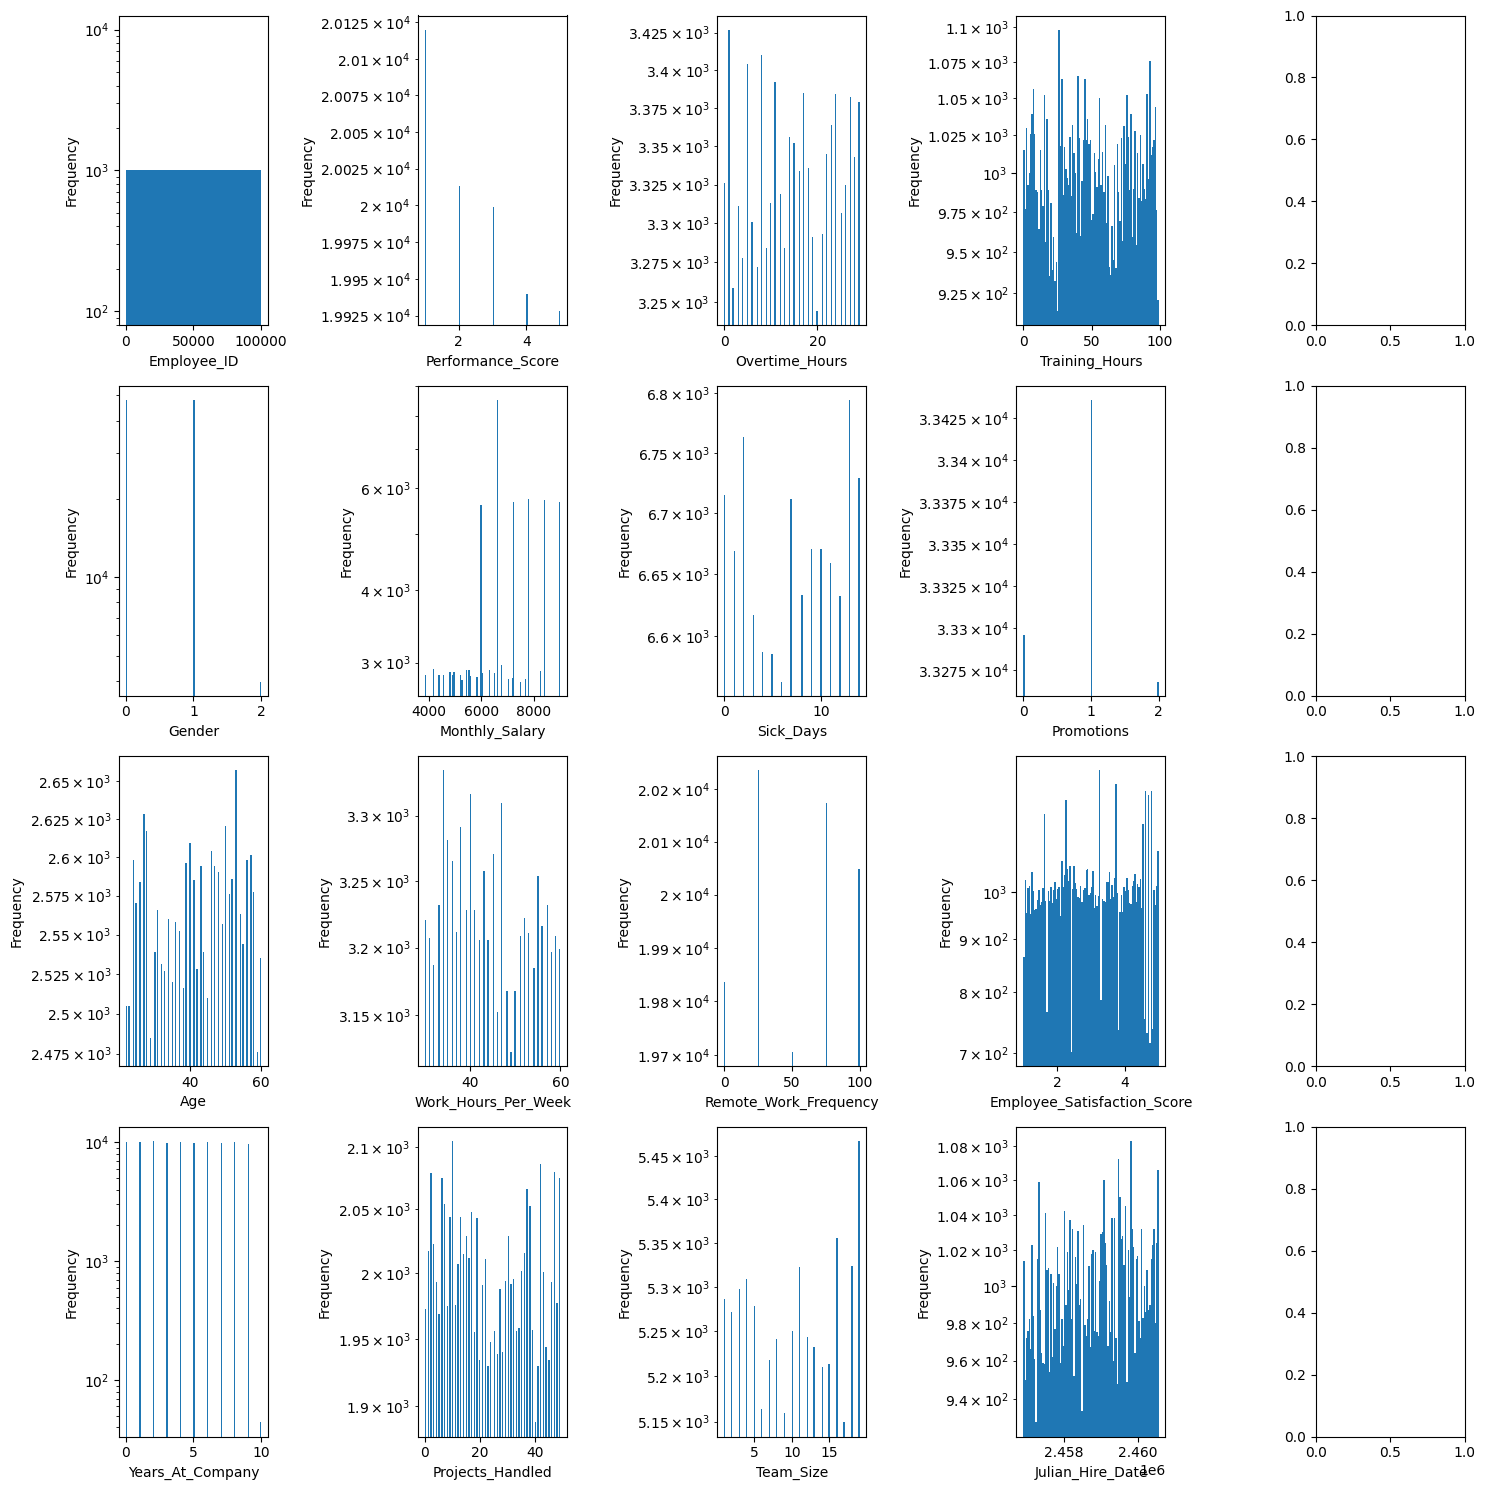

In [95]:
dataCleaner = DataFrameTransformer(df_dummies)
DataFrameTransformer.plot_histogram(df_dummies)

In [96]:
df_box_coxed_transformed = dataCleaner.boxcox_transform(df_dummies.select_dtypes(include=['number']).columns.tolist())
display(df_box_coxed_transformed.head(2))

,Employee_ID,Gender,Age,Hire_Date,Years_At_Company,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,...,Department_8,Education_Level_1,Education_Level_2,Education_Level_3,Job_Title_1,Job_Title_2,Job_Title_3,Job_Title_4,Job_Title_5,Job_Title_6
0,9.999999e-07,9.999995e-07,26.278482,2022-01-19 08:03:05.556036,0.796856,2.936687,368.370925,15.751740,9.693337,7.14586,...,False,True,False,False,False,False,False,False,True,False
1,8.945474e-01,9.999995e-07,15.658568,2024-04-18 08:03:05.556036,-2.530988,2.936687,393.166476,16.123167,10.064168,5.07736,...,False,True,False,False,False,True,False,False,False,False


Now we can plot histograms again

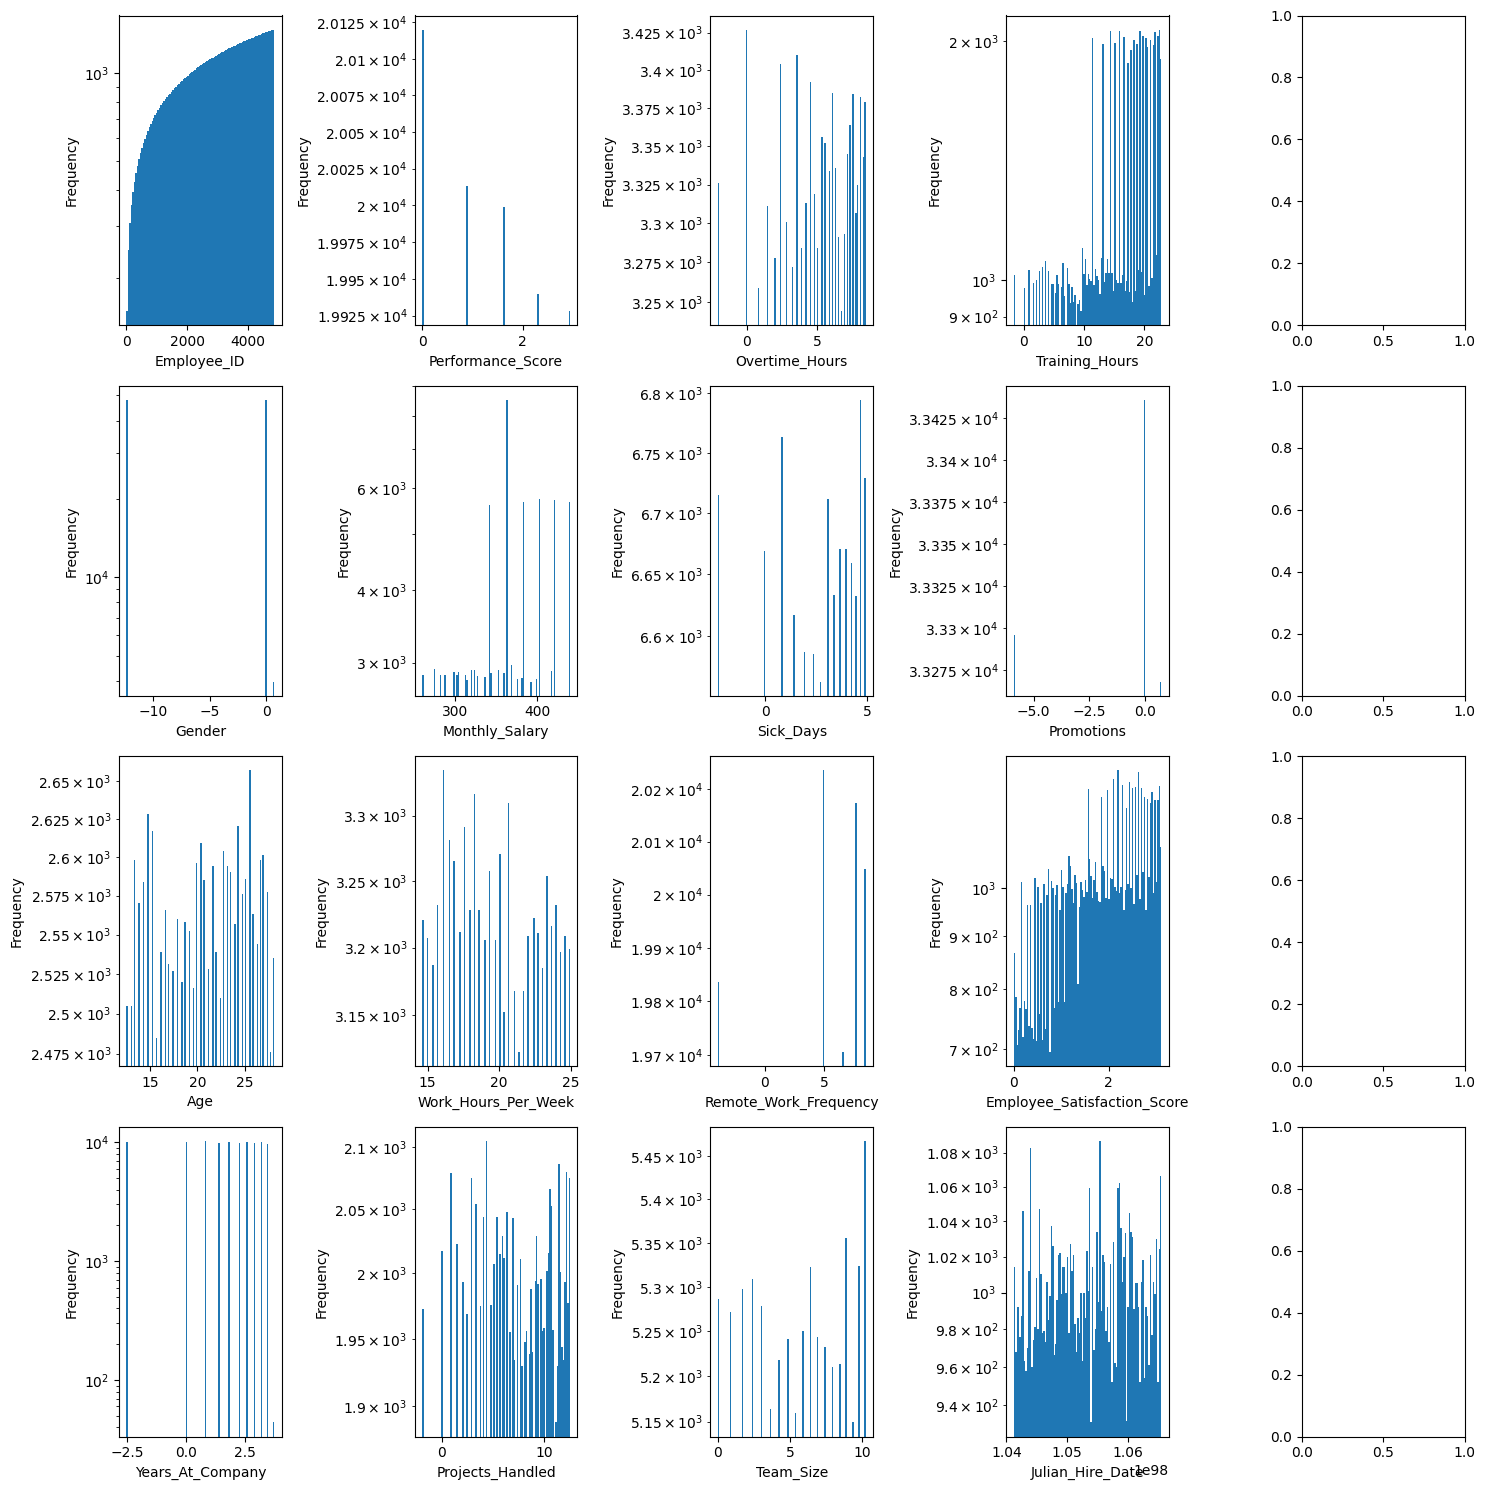

In [97]:
DataFrameTransformer.plot_histogram(df_box_coxed_transformed)

#### **5. Tukeys Ladder**

After examining the plots we got from box-cox transformation.

Skewed features : 
- Work Hours Per week
- Performance Score

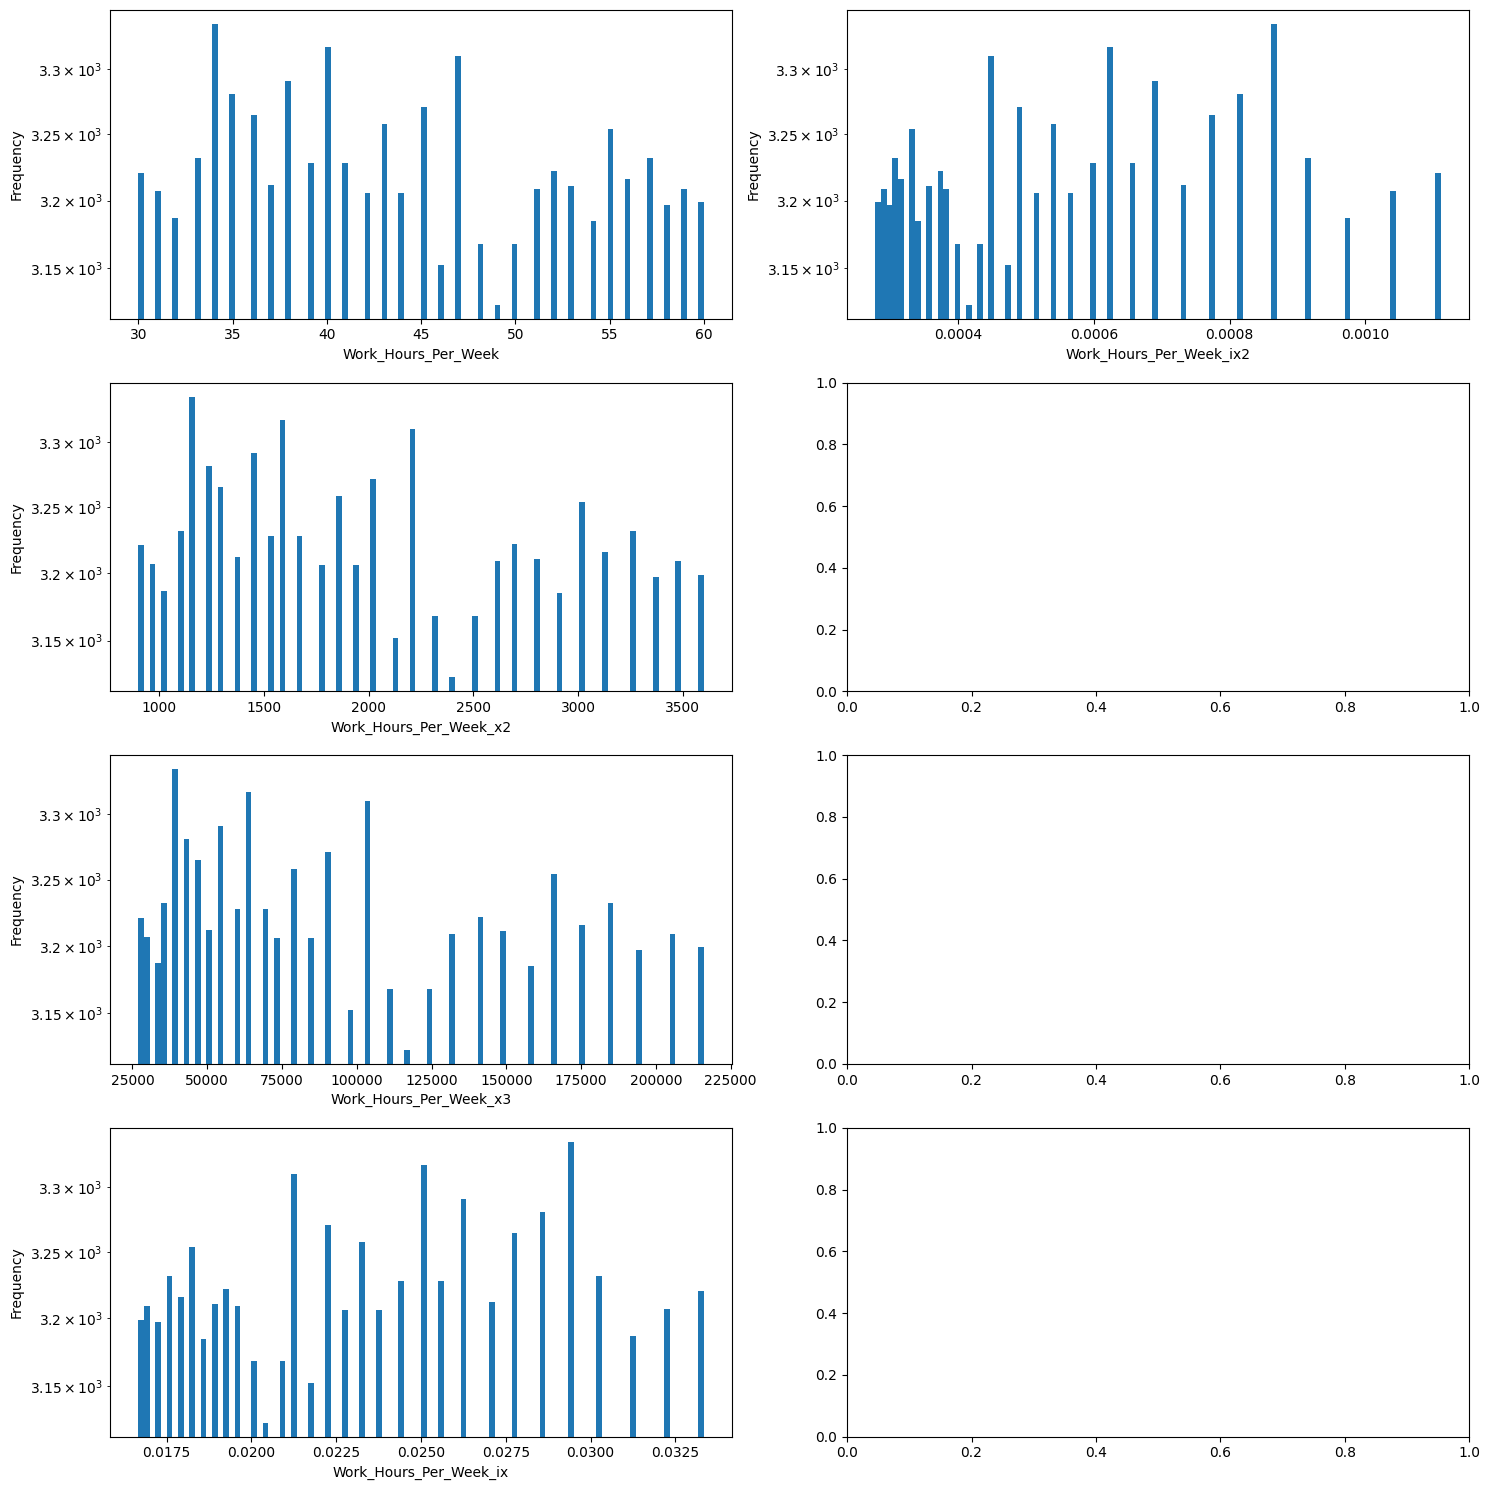

In [98]:
dataframeTransformer = DataFrameTransformer(df_box_coxed_transformed)
dataframeTransformer.plot_tukey_ladder("Work_Hours_Per_Week")


Performance Score

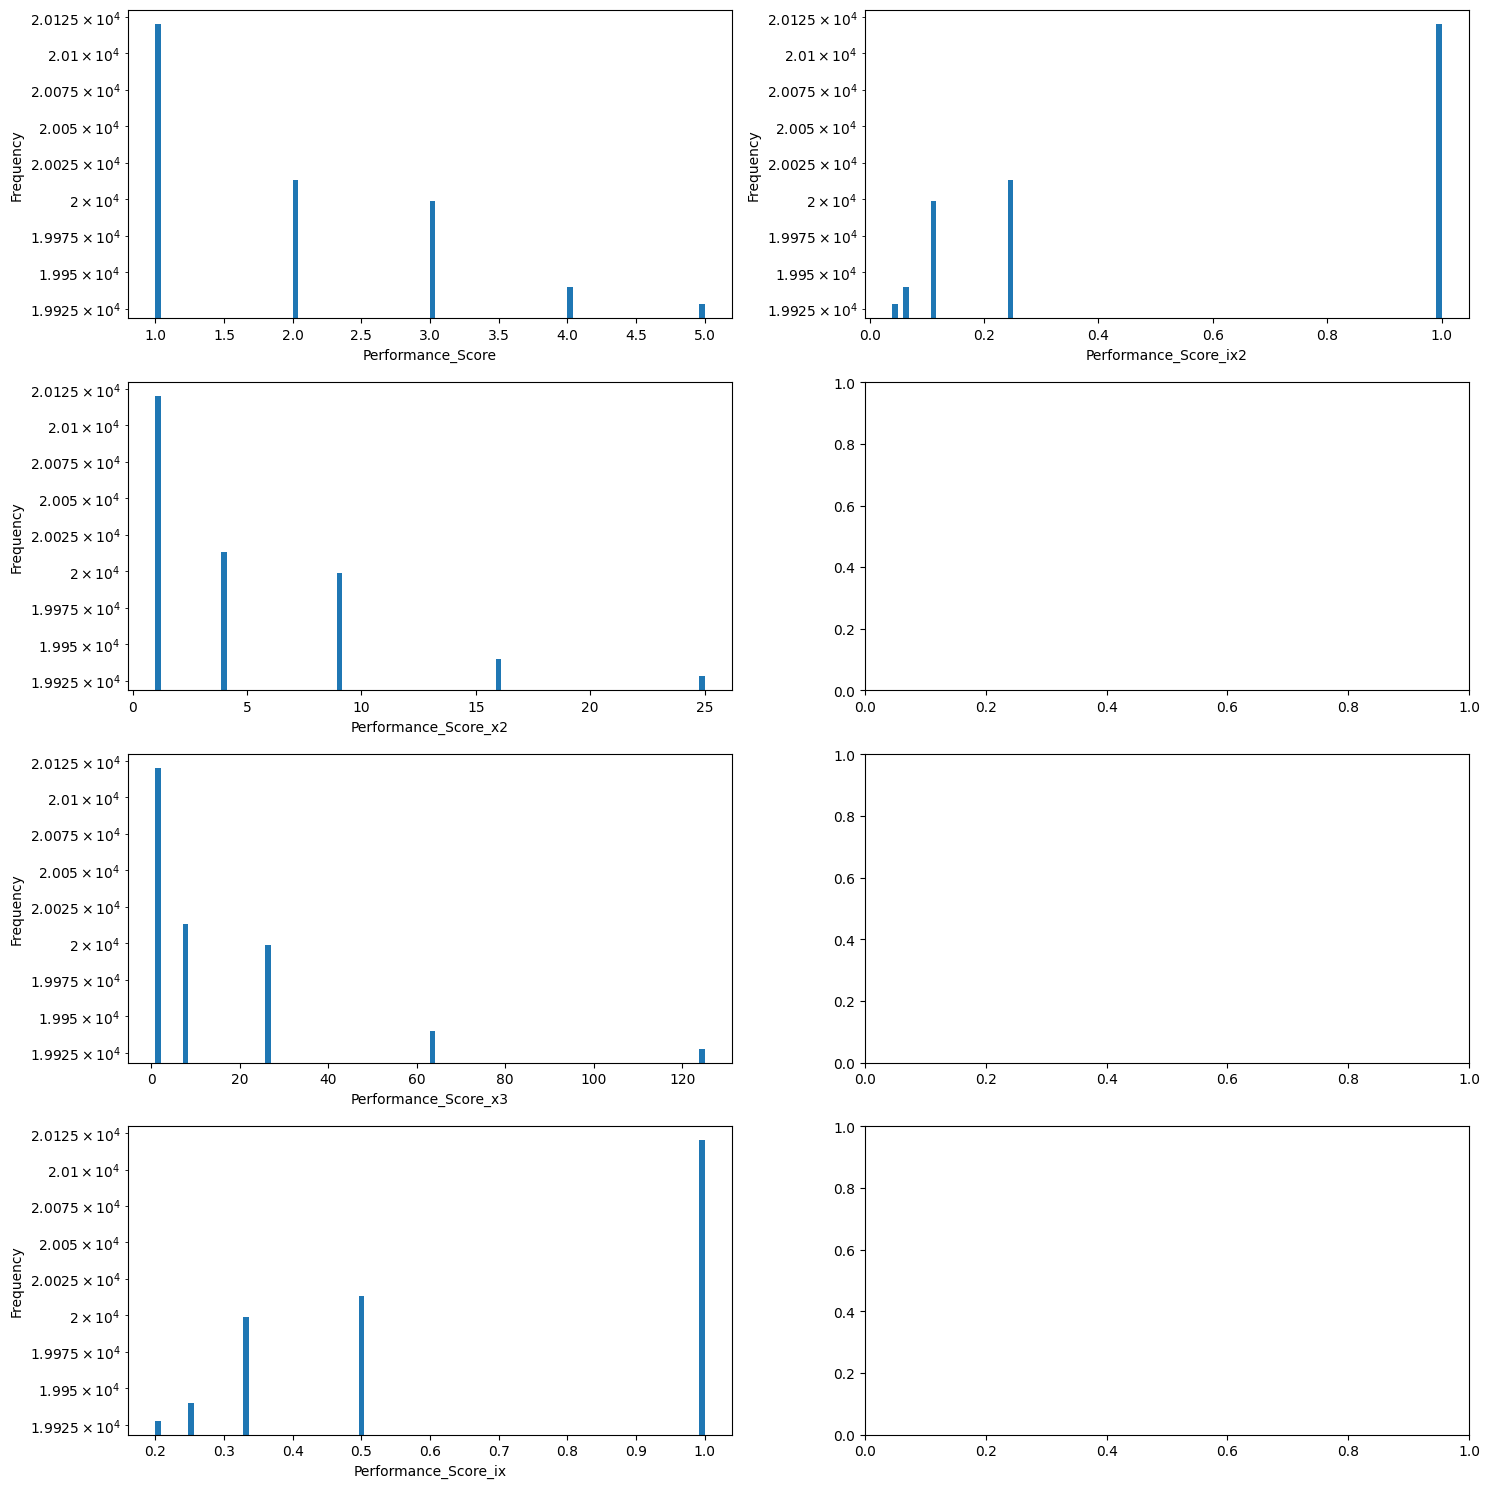

In [99]:
dataframeTransformer = DataFrameTransformer(df_box_coxed_transformed)
dataframeTransformer.plot_tukey_ladder("Performance_Score")

No significant use after performing tukeys on Performance Score Hence ignore.

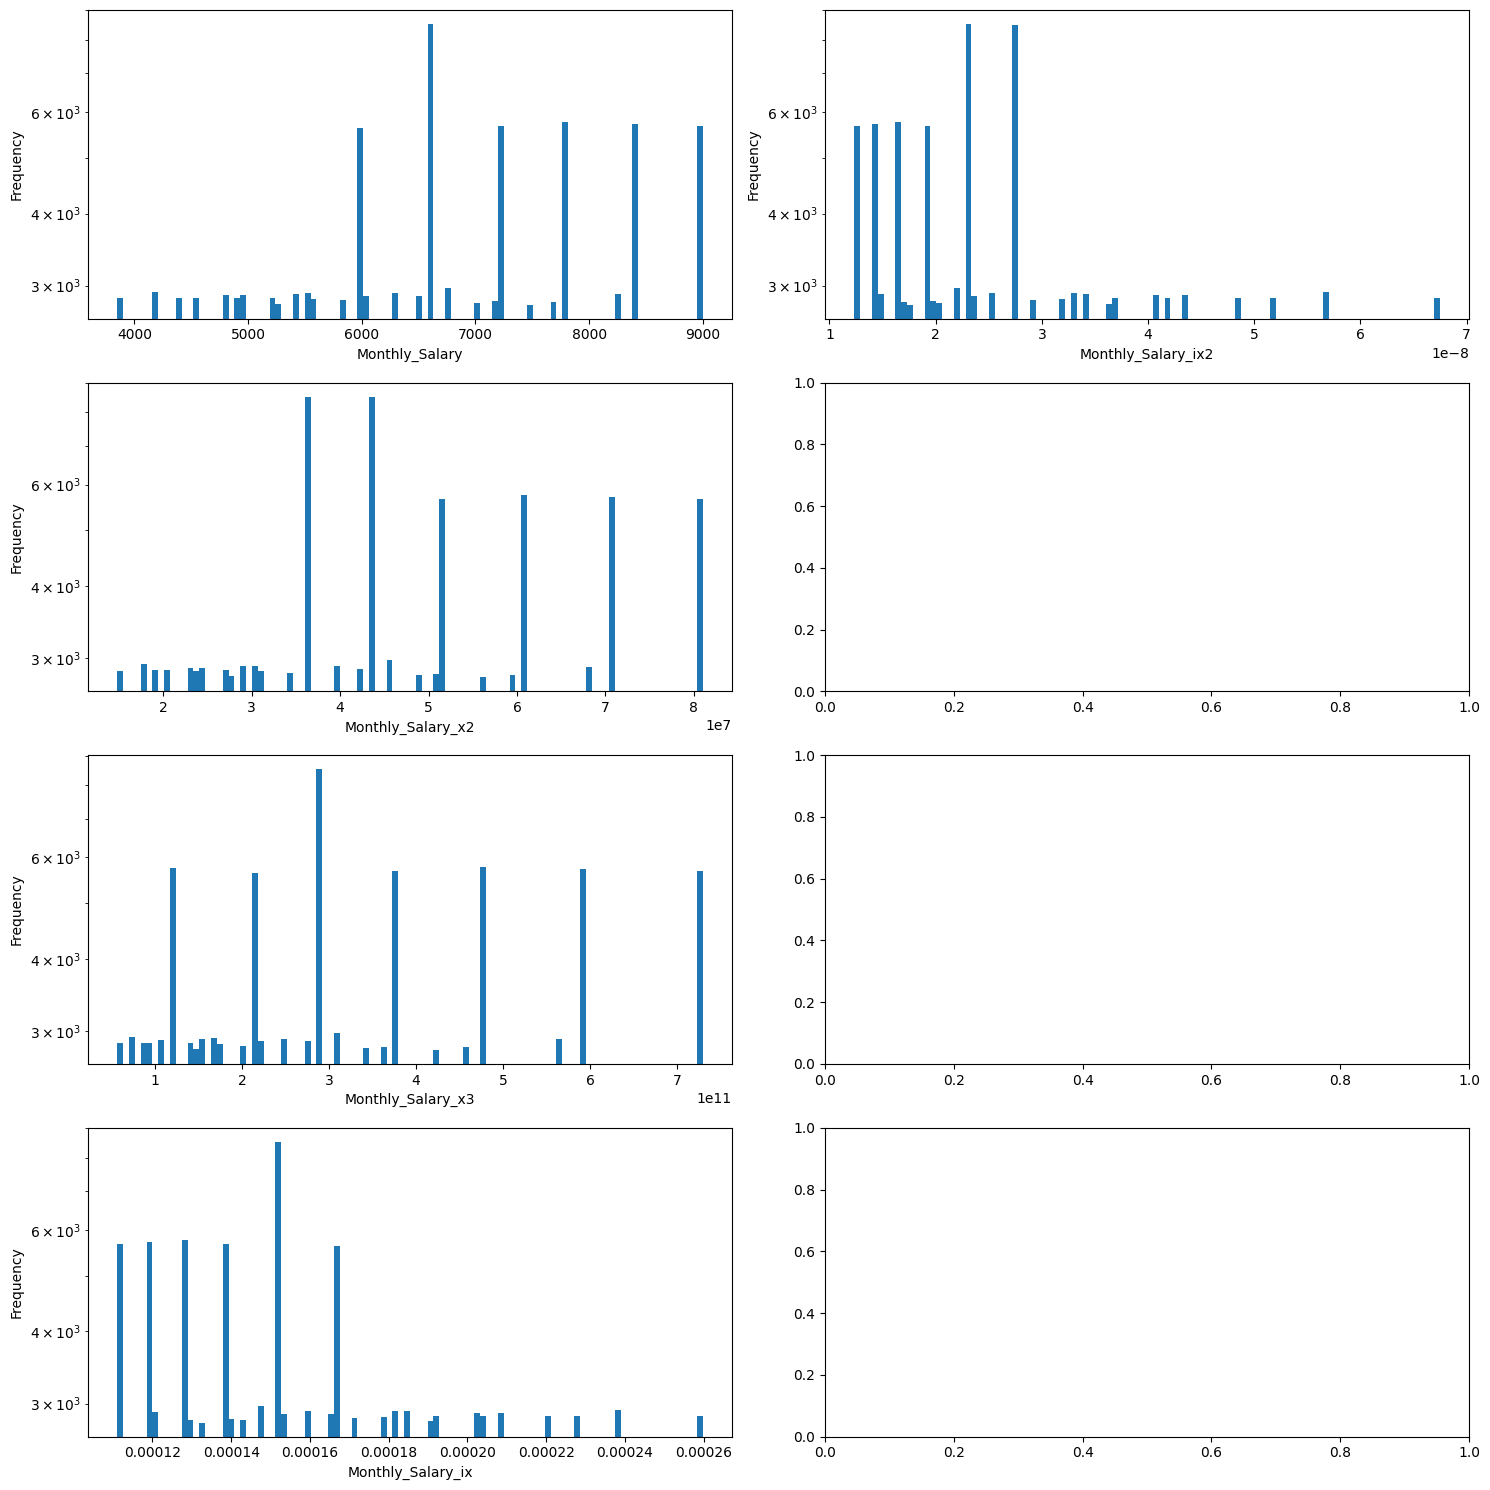

In [100]:
dataframeTransformer = DataFrameTransformer(df_box_coxed_transformed)
dataframeTransformer.plot_tukey_ladder("Monthly_Salary")

#### **6. Perform SLR and MLR methods and analyze the results**

SLR (Simple Linear Regression) and MLR (Multiple Linear Regression) are statistical techniques used to model and analyze relationships between dependent and independent variables.
> SLR helps explore simple relationships (e.g., how one variable affects another).

> MLR helps understand complex interactions by considering multiple factors simultaneously.

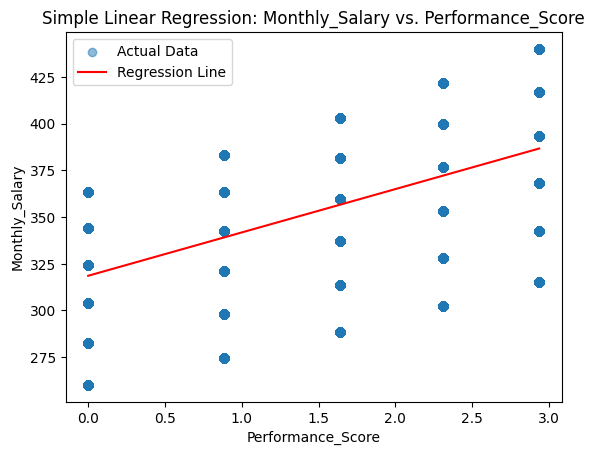

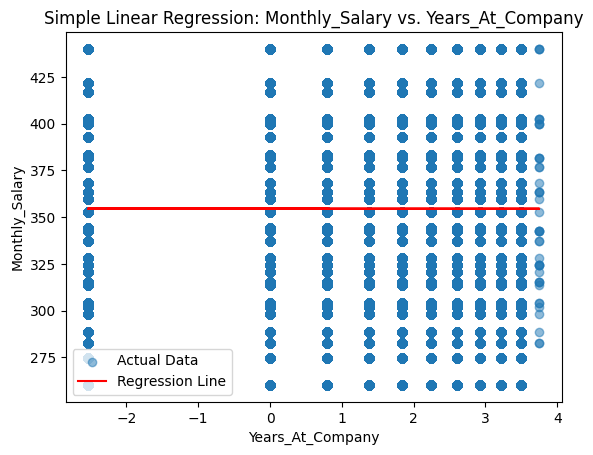

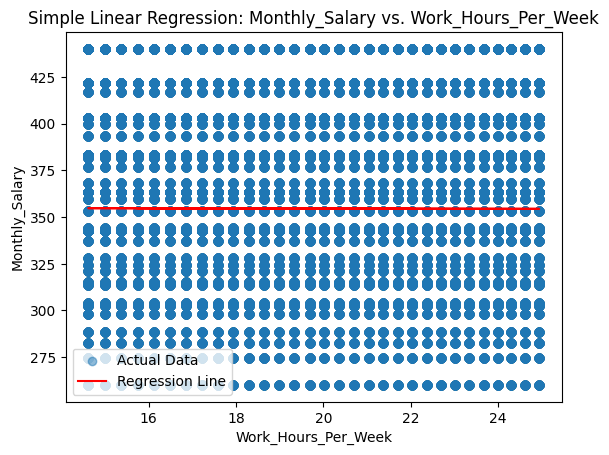

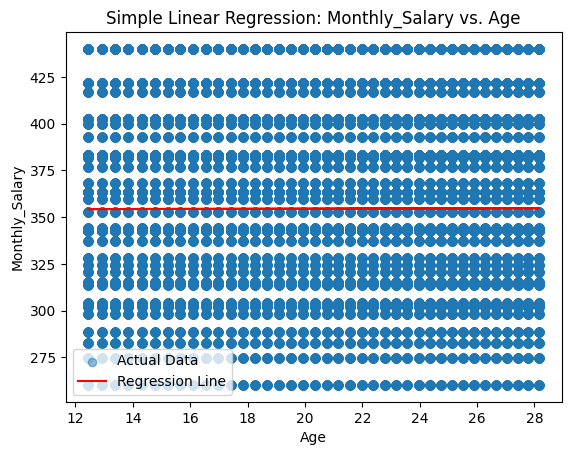

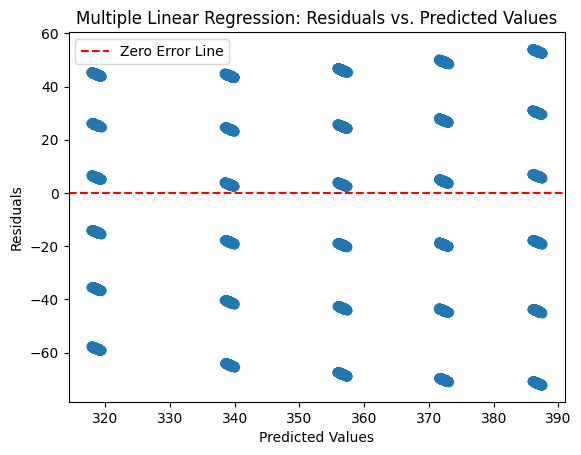

In [101]:
dataframeTransformer.plot_simple_linear_regression(y_column="Monthly_Salary", x_column="Performance_Score")
dataframeTransformer.plot_simple_linear_regression(y_column="Monthly_Salary", x_column="Years_At_Company")
dataframeTransformer.plot_simple_linear_regression(y_column="Monthly_Salary", x_column="Work_Hours_Per_Week")
dataframeTransformer.plot_simple_linear_regression(y_column="Monthly_Salary", x_column="Age")

dataframeTransformer.plot_multiple_linear_regression(
    y_column="Monthly_Salary", 
    x_columns=[
        "Performance_Score",
        "Work_Hours_Per_Week",
        "Projects_Handled",
        "Years_At_Company",
        "Team_Size",
        "Employee_Satisfaction_Score"
    ]
)



In [103]:
dataframeTransformer.simple_linear_regression(y_column="Monthly_Salary", x_column="Performance_Score")
dataframeTransformer.simple_linear_regression(y_column="Monthly_Salary", x_column="Years_At_Company")
dataframeTransformer.simple_linear_regression(y_column="Monthly_Salary", x_column="Work_Hours_Per_Week")
dataframeTransformer.simple_linear_regression(y_column="Monthly_Salary", x_column="Age")

dataframeTransformer.multiple_linear_regression(
    y_column="Monthly_Salary", 
    x_columns=[
        "Performance_Score",
        "Work_Hours_Per_Week",
        "Projects_Handled",
        "Years_At_Company",
        "Team_Size",
        "Employee_Satisfaction_Score"
    ]
)

dataframeTransformer.multiple_linear_regression(
    y_column="Employee_Satisfaction_Score", 
    x_columns=[
        "Performance_Score",
        "Work_Hours_Per_Week",
        "Projects_Handled",
        "Years_At_Company",
        "Team_Size",
        "Remote_Work_Frequency",
        "Monthly_Salary"
    ]
)

dataframeTransformer.multiple_linear_regression(
    y_column="Performance_Score", 
    x_columns=[
        "Employee_Satisfaction_Score",
        "Work_Hours_Per_Week",
        "Projects_Handled",
        "Years_At_Company",
        "Remote_Work_Frequency",
        "Team_Size",
        "Monthly_Salary"
    ]
)

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      Performance_Score   R-squared:                       0.255
Model:                            OLS   Adj. R-squared:                  0.255
Method:                 Least Squares   F-statistic:                     4896.
Date:                Thu, 21 Nov 2024   Prob (F-statistic):               0.00
Time:                        00:22:43   Log-Likelihood:            -1.3065e+05
No. Observations:              100000   AIC:                         2.613e+05
Df Residuals:                   99992   BIC:                         2.614e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
===============================================================================================
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                          -2.3182      0.030    -77.440      0.000      -2.377      -2.260
Employee_Satisfaction_Score     0.0015      0.003      0.477      0.633      -0.005       0.008
Work_Hours_Per_Week            -0.0015      0.001     -1.599      0.110      -0.003       0.000
Projects_Handled                0.0003      0.001      0.399      0.690      -0.001       0.002
Years_At_Company                0.0010      0.002      0.606      0.545      -0.002       0.004
Remote_Work_Frequency           0.0008      0.001      1.323      0.186      -0.000       0.002
Team_Size                      -0.0023      0.001     -2.486      0.013      -0.004      -0.000
Monthly_Salary                  0.0110   5.95e-05    185.093      0.000       0.011       0.011
==============================================================================
Omnibus:                     7198.349   Durbin-Watson:                   2.002
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2443.576
Skew:                          -0.021   Prob(JB):                         0.00
Kurtosis:                       2.235   Cond. No.                     3.80e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.8e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""